In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import fisher_exact
import numpy as np
from fontTools.misc.cython import returns
from gprofiler import GProfiler

In [2]:
#!pip install gprofiler-official

In [3]:
comparison_final = pd.read_csv('comparison_df.csv')
comparison_final.head()
#comparison_final.shape[0]

,seqid_suzukii,gene_name,gene_start_suzukii,gene_end_suzukii,strand_suzukii,te_family_name_suzukii,te_class_suzukii,overlap_type_suzukii,attributes_suzukii,seqid_melano,...,gene_end_melano,strand_melano,te_family_name_melano,te_class_melano,overlap_type_melano,attributes_melano,te_family_diff,te_class_diff,overlap_type_diff,has_difference
0,NC_092080.1,l(2)gl,39066,43325,-,nf_25_CR1_1,LINE/CR1,upstream,ID=gene-Dmel_CG2671;Dbxref=FLYBASE:FBgn0002121...,NT_033779.5,...,21376.0,-,DNAREP1_DM,DNA/RC,instream,ID=gene-Dmel_CG2671;Dbxref=FLYBASE:FBgn0002121...,True,True,True,True
1,NC_092080.1,ir21a,50903,53161,-,nf_26_COPIA_1,LTR/COPIA,upstream,ID=gene-Dmel_CG2657;Dbxref=FLYBASE:FBgn0031209...,NT_033779.5,...,25155.0,-,DNAREP1_DM,DNA/RC,instream,ID=gene-Dmel_CG2657;Dbxref=FLYBASE:FBgn0031209...,True,True,True,True
2,NC_092080.1,asrna:cr43609,50903,53181,+,nf_26_COPIA_1,LTR/COPIA,upstream,ID=gene-Dmel_CR43609;Dbxref=FLYBASE:FBgn026358...,NT_033779.5,...,24237.0,+,DNAREP1_DM,DNA/RC,instream,ID=gene-Dmel_CR43609;Dbxref=FLYBASE:FBgn026358...,True,True,True,True
3,NC_092080.1,cda5,54610,89429,-,nf_26_COPIA_1,LTR/COPIA,upstream,ID=gene-Dmel_CG31973;Dbxref=FLYBASE:FBgn005197...,NT_033779.5,...,65404.0,-,DNAREP1_DM,DNA/RC,upstream,ID=gene-Dmel_CG31973;Dbxref=FLYBASE:FBgn005197...,True,True,False,True
4,NC_092080.1,lncrna:cr46254,84208,84744,+,NaN,NaN,NaN,ID=gene-Dmel_CR46254;Dbxref=FLYBASE:FBgn026798...,NT_033779.5,...,55767.0,+,Jockey,LINE/JOCKEY,upstream,ID=gene-Dmel_CR46254;Dbxref=FLYBASE:FBgn026798...,True,True,True,True


In [4]:
filtered_df = comparison_final[
    (comparison_final['overlap_type_suzukii'].notna()) &
    (comparison_final['overlap_type_melano'].isna())
]
filtered_df.shape[0]

4478

In [5]:
genes = []
description = []
te_classes = [] # Lista adicional para almacenar 'te_class_suzukii'
te_family = []
gene_name = []

obj4_result = pd.DataFrame(columns=['gen', 'gene_name', 'description', 'te_family_suzukii','te_class_suzukii'])  # Añadir la nueva columna

for index, row in filtered_df.iterrows():
    # Obtener el gene_name
    attributes_parts = row['attributes_suzukii'].split(';')

    gene_part = attributes_parts[0]
    gene = gene_part.split("gene-")[1]
    gene = gene.replace("Dmel_", "")
    genes.append(gene)

    # Obtener nombre de los genes
    gene_name.append(row['gene_name'])

    # Obtener el description de los atributos

    desc = attributes_parts[4].split('=')[1]
    final_desc = ''.join(desc.rsplit(' ', 1)[:-1])
    description.append(final_desc)

    #Obtener la familia de TE
    te_family.append(row['te_family_name_suzukii'])

    # Obtener la clase de TE
    te_classes.append(row['te_class_suzukii'])  # Almacenar 'te_class_suzukii'

# Asignar las listas al DataFrame
obj4_result['gen'] = genes
obj4_result['gene_name'] = gene_name
obj4_result['description'] = description
obj4_result['te_family_suzukii'] = te_family
obj4_result['te_class_suzukii'] = te_classes  # Añadir la nueva columna

# Mostrar los primeros registros del DataFrame
obj4_result.head()
obj4_result.to_csv("overall_genes_description.csv")

In [6]:
obj4_result.head()

,gen,gene_name,description,te_family_suzukii,te_class_suzukii
0,CG11374,cg11374,,nf_47_GYPSY_1,LTR/GYPSY
1,CG11450,net,,nf_47_GYPSY_1,LTR/GYPSY
2,CG11376,zir,,nf_23_HELITRON_1,DNA/RC
3,CG11377,creld,Cysteine rich with EGF like,nf_23_HELITRON_1,DNA/RC
4,CR44185,lncrna:cr44185,long non-coding,nf_138_GYPSY_1,LTR/GYPSY


In [7]:
genes_with_te_counts = obj4_result['gene_name'].value_counts()
print(genes_with_te_counts)

gene_name
mod(mdg4)    16
med15         1
cg9044        1
cg11374       1
net           1
             ..
tsp26a        1
pfas          1
ipip          1
cg13999       1
trni          1
Name: count, Length: 4463, dtype: int64


In [8]:
filtered_df.head()

,seqid_suzukii,gene_name,gene_start_suzukii,gene_end_suzukii,strand_suzukii,te_family_name_suzukii,te_class_suzukii,overlap_type_suzukii,attributes_suzukii,seqid_melano,...,gene_end_melano,strand_melano,te_family_name_melano,te_class_melano,overlap_type_melano,attributes_melano,te_family_diff,te_class_diff,overlap_type_diff,has_difference
8,NC_092080.1,cg11374,107454,108726,+,nf_47_GYPSY_1,LTR/GYPSY,downstream,ID=gene-Dmel_CG11374;Dbxref=FLYBASE:FBgn003121...,NT_033779.5,...,77783.0,+,NaN,NaN,NaN,ID=gene-Dmel_CG11374;Dbxref=FLYBASE:FBgn003121...,True,True,True,True
9,NC_092080.1,net,117341,121822,-,nf_47_GYPSY_1,LTR/GYPSY,upstream,ID=gene-Dmel_CG11450;Dbxref=FLYBASE:FBgn000293...,NT_033779.5,...,87387.0,-,NaN,NaN,NaN,ID=gene-Dmel_CG11450;Dbxref=FLYBASE:FBgn000293...,True,True,True,True
10,NC_092080.1,zir,131608,138568,+,nf_23_HELITRON_1,DNA/RC,instream,ID=gene-Dmel_CG11376;Dbxref=FLYBASE:FBgn003121...,NT_033779.5,...,102086.0,+,NaN,NaN,NaN,ID=gene-Dmel_CG11376;Dbxref=FLYBASE:FBgn003121...,True,True,True,True
11,NC_092080.1,creld,145478,147384,+,nf_23_HELITRON_1,DNA/RC,upstream,ID=gene-Dmel_CG11377;Dbxref=FLYBASE:FBgn003121...,NT_033779.5,...,104142.0,+,NaN,NaN,NaN,ID=gene-Dmel_CG11377;Dbxref=FLYBASE:FBgn003121...,True,True,True,True
17,NC_092080.1,lncrna:cr44185,179673,179950,+,nf_138_GYPSY_1,LTR/GYPSY,downstream,ID=gene-Dmel_CR44185;Dbxref=FLYBASE:FBgn026507...,NT_033779.5,...,136128.0,+,NaN,NaN,NaN,ID=gene-Dmel_CR44185;Dbxref=FLYBASE:FBgn026507...,True,True,True,True


In [9]:
# Filtrar el DataFrame para encontrar las filas que contienen las palabras clave en 'attributes_suzukii'
filtered_genes = filtered_df[
    filtered_df['attributes_suzukii'].str.contains('ionotropic|odorant|gustatory', case=False, na=False)
]

# Mostrar el DataFrame filtrado
filtered_genes.head()

,seqid_suzukii,gene_name,gene_start_suzukii,gene_end_suzukii,strand_suzukii,te_family_name_suzukii,te_class_suzukii,overlap_type_suzukii,attributes_suzukii,seqid_melano,...,gene_end_melano,strand_melano,te_family_name_melano,te_class_melano,overlap_type_melano,attributes_melano,te_family_diff,te_class_diff,overlap_type_diff,has_difference
105,NC_092080.1,or24a,1371887,1373463,+,nf_158_LTR_1,LTR/LTR,upstream,ID=gene-Dmel_CG11767;Dbxref=FLYBASE:FBgn002639...,NT_033779.5,...,4166134.0,-,NaN,NaN,NaN,ID=gene-Dmel_CG11767;Dbxref=FLYBASE:FBgn002639...,True,True,True,True
507,NC_092080.1,gr22e,8454377,8455604,+,nf_23_HELITRON_1,DNA/RC,upstream,ID=gene-Dmel_CG31936;Dbxref=FLYBASE:FBgn004549...,NT_033779.5,...,1785286.0,+,NaN,NaN,NaN,ID=gene-Dmel_CG31936;Dbxref=FLYBASE:FBgn004549...,True,True,True,True
654,NC_092080.1,or35a,10315240,10316730,-,nf_293_LINE_1,LINE/I,upstream,ID=gene-Dmel_CG17868;Dbxref=FLYBASE:FBgn002894...,NT_033779.5,...,15623558.0,-,NaN,NaN,NaN,ID=gene-Dmel_CG17868;Dbxref=FLYBASE:FBgn002894...,True,True,True,True
1642,NC_092080.1,gr33a,22641768,22643102,+,nf_360_HELITRON_1,DNA/RC,upstream,ID=gene-Dmel_CG17213;Dbxref=FLYBASE:FBgn003241...,NT_033779.5,...,12140392.0,+,NaN,NaN,NaN,ID=gene-Dmel_CG17213;Dbxref=FLYBASE:FBgn003241...,True,True,True,True
2044,NC_092081.1,or49b,3363718,3365560,-,nf_81_I_1,LINE/I,upstream,ID=gene-Dmel_CG17584;Dbxref=FLYBASE:FBgn002896...,NT_033778.4,...,12844704.0,+,NaN,NaN,NaN,ID=gene-Dmel_CG17584;Dbxref=FLYBASE:FBgn002896...,True,True,True,True


In [10]:
filtered_genes.shape[0]

59

In [11]:
genes = []
description = []
te_classes = []  # Lista adicional para almacenar 'te_class_suzukii'
te_family = []
gene_name = []
obj3_result = pd.DataFrame(columns=['gen', 'gene_name', 'description', 'te_family_suzukii', 'te_class_suzukii'])  # Añadir la nueva columna

for index, row in filtered_genes.iterrows():
    gene_part = attributes_parts[0]
    gene = gene_part.split("gene-")[1]
    gene = gene.replace("Dmel_", "")
    genes.append(gene)

    # Obtener nombre de los genes
    gene_name.append(row['gene_name'])

    # Obtener el description de los atributos
    attributes_parts = row['attributes_suzukii'].split(';')
    desc = attributes_parts[4].split('=')[1]
    final_desc = ''.join(desc.rsplit(' ', 1)[:-1])
    description.append(final_desc)

    #Obtener la familia de TE
    te_family.append(row['te_family_name_suzukii'])

    # Obtener la clase de TE
    te_classes.append(row['te_class_suzukii'])  # Almacenar 'te_class_suzukii'

# Asignar las listas al DataFrame
obj3_result['gen'] = genes
obj3_result['description'] = description
obj3_result['gene_name'] = gene_name
obj3_result['te_family_suzukii'] = te_family
obj3_result['te_class_suzukii'] = te_classes  # Añadir la nueva columna

# Mostrar los primeros registros del DataFrame
obj3_result.head()

,gen,gene_name,description,te_family_suzukii,te_class_suzukii
0,CG9044,or24a,Odorant receptor,nf_158_LTR_1,LTR/LTR
1,CG11767,gr22e,Gustatory receptor,nf_23_HELITRON_1,DNA/RC
2,CG31936,or35a,Odorant receptor,nf_293_LINE_1,LINE/I
3,CG17868,gr33a,Gustatory receptor,nf_360_HELITRON_1,DNA/RC
4,CG17213,or49b,Odorant receptor,nf_81_I_1,LINE/I


In [12]:
obj3_result["te_family_suzukii"].unique()

array(['nf_158_LTR_1', 'nf_23_HELITRON_1', 'nf_293_LINE_1',
       'nf_360_HELITRON_1', 'nf_81_I_1', 'nf_328_P_1', 'nf_381_TIR_1',
       'nf_291_TIR_1', 'nf_369_LTR_1', 'nf_10_TIR_1', 'nf_143_GYPSY_2',
       'nf_274_GYPSY_1', 'nf_117_TIR_1', 'nf_25_CR1_1', 'P-1_DRh_inc_1',
       'nf_159_LINE_1', 'I-6_DBp', 'nf_292_LTR_1', 'nf_111_GYPSY_1',
       'NINJA_I'], dtype=object)

In [13]:
obj3_result.shape[0]

59

In [14]:
obj3_result.to_csv('food_consumption_related_genes.csv', index=False)

In [15]:
genes_org = []
description_org = []
te_classes_org = []  # Lista adicional para almacenar 'te_class_suzukii'
obj3_result_org = pd.DataFrame(columns=['gen', 'description', 'te_class_suzukii'])  # Añadir la nueva columna

for index, row in filtered_df.iterrows():
    # Obtener el gene_name
    genes_org.append(row['gene_name'])

    # Obtener la description de los atributos
    attributes_parts = row['attributes_suzukii'].split(';')
    desc = attributes_parts[4].split('=')[1]
    final_desc = ''.join(desc.rsplit(' ', 1)[:-1])
    description_org.append(final_desc)

    # Obtener la clase de TE
    te_classes_org.append(row['te_class_suzukii'])  # Almacenar 'te_class_suzukii'

# Asignar las listas al DataFrame
obj3_result_org['gen'] = genes_org
obj3_result_org['description'] = description_org
obj3_result_org['te_class_suzukii'] = te_classes_org  # Añadir la nueva columna

# Mostrar los primeros registros del DataFrame
print(obj3_result_org.head())

# Guardar el DataFrame en un archivo CSV
obj3_result_org.to_csv('org_food_consumption_related_genes_with_te_class.csv', index=False)

              gen                  description te_class_suzukii
0         cg11374                                     LTR/GYPSY
1             net                                     LTR/GYPSY
2             zir                                        DNA/RC
3           creld  Cysteine rich with EGF like           DNA/RC
4  lncrna:cr44185              long non-coding        LTR/GYPSY


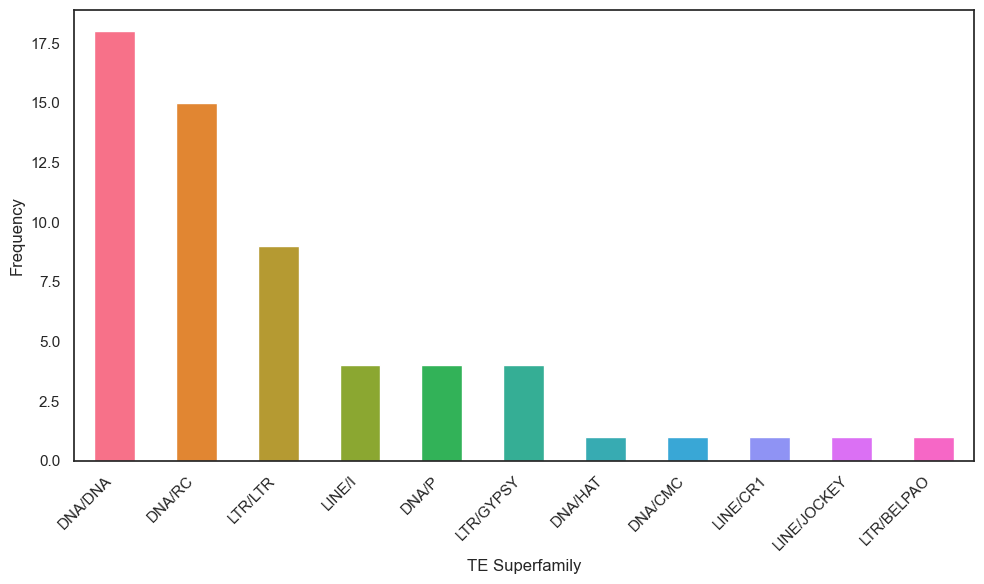

In [16]:
# Calcular la frecuencia de cada superfamilia de TE
te_class_counts = obj3_result['te_class_suzukii'].value_counts()

# Configurar el estilo y la paleta de colores usando seaborn
sns.set(style="white")  # Cambiar el estilo a "white" para eliminar la cuadrícula
palette = sns.color_palette("husl", len(te_class_counts))  # Paleta de colores "husl" para una mejor diferenciación

# Crear un gráfico de barras para mostrar la frecuencia de cada superfamilia de TEs
plt.figure(figsize=(10, 6))
te_class_counts.plot(kind='bar', color=palette)
#plt.title('Frequency of TE superfamilies inserted in food consumption-related genes of D. suzukii')
plt.xlabel('TE Superfamily')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')

# Eliminar la cuadrícula explícitamente si el estilo no lo hace por completo
plt.grid(False)

# Guardar la imagen en el archivo especificado
plt.tight_layout()
plt.savefig('superfamilies_frecuency_in_genes.pdf', format='pdf', dpi=300)
plt.show()

In [17]:
freq_obj3 = obj3_result['te_class_suzukii'].value_counts(normalize=True)
freq_obj4 = obj4_result['te_class_suzukii'].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    'obj3': freq_obj3,
    'obj4': freq_obj4
}).fillna(0)

comparison_df = comparison_df * 100

comparison_df['total'] = comparison_df['obj3'] + comparison_df['obj4']
comparison_df = comparison_df.sort_values('total', ascending=False).drop(columns='total')

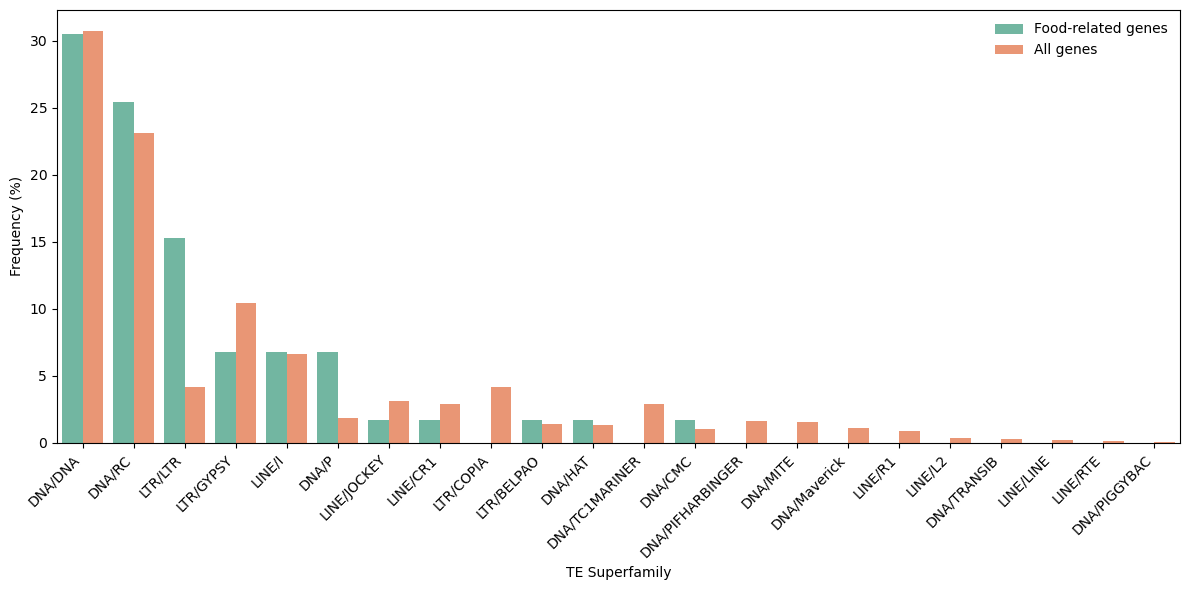

In [37]:
# Reorganizar datos a formato largo
comparison_df = comparison_df.rename(columns={
    'obj3': 'Food-related genes',
    'obj4': 'All genes'
})

df_long = comparison_df.reset_index().melt(
    id_vars='te_class_suzukii',
    var_name='Dataset',
    value_name='Frequency'
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_long,
    x='te_class_suzukii',
    y='Frequency',
    hue='Dataset',
    palette=['#66c2a5', '#fc8d62']
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('TE Superfamily')
plt.ylabel('Frequency (%)')
plt.legend(frameon=False)
plt.grid(False)

plt.tight_layout()
plt.savefig('superfamilies_frecuency_in_food_genes.pdf', format='pdf', dpi=300)
plt.show()

In [19]:
te = 'LTR/LTR'
total_obj3 = len(obj3_result)
total_obj4 = len(obj4_result)

a = (obj3_result['te_class_suzukii'] == te).sum()
b = total_obj3 - a
c = (obj4_result['te_class_suzukii'] == te).sum()
d = total_obj4 - c

contingency_table = [[a, b],
                     [c, d]]

print(contingency_table)

[[np.int64(9), np.int64(50)], [np.int64(186), np.int64(4292)]]


In [20]:
odds_ratio, p_value = fisher_exact(contingency_table)

print(f"Odds ratio: {odds_ratio}")
print(f"P-value: {p_value}")

Odds ratio: 4.153548387096774
P-value: 0.0008079745062488095


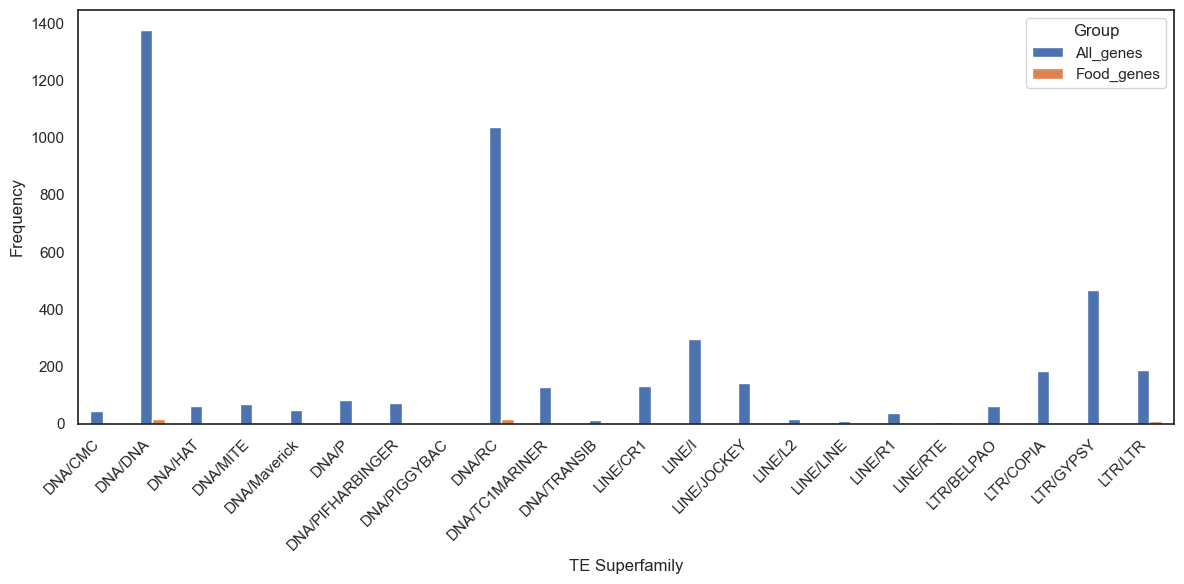

In [21]:
###Todos los genes en comparación con los genes atribuídos a la alimentación

food_genes_te_count = obj3_result['te_class_suzukii'].value_counts()
all_genes_te_count = obj4_result['te_class_suzukii'].value_counts()
all_genes_te_count, food_genes_te_count = all_genes_te_count.align(food_genes_te_count, fill_value=0)

food_vs_all_df= pd.DataFrame({
    "All_genes": all_genes_te_count,
    "Food_genes": food_genes_te_count,
})

sns.set(style="white")

food_vs_all_df.plot(
    kind='bar',
    figsize=(12,6)
)

plt.xlabel('TE Superfamily')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.legend(title="Group")

plt.tight_layout()
plt.savefig('comparison_TE_superfamilies.png', dpi=300)
plt.show()

In [22]:
###Validación estadística TEs enriquecidos en genes de alimentación###
gff_file = "suzukii_transfer_annotation_v2.gff"

genes_gff = pd.read_csv(
    gff_file,
    sep="\t",
    comment="#",
    header=None
)

genes_gff.columns = [
    "seqid", "source", "type", "start", "end",
    "score", "strand", "phase", "attributes"
]

genes_gff = genes_gff[genes_gff["type"] == "gene"].copy()

def extract_gene_id(attr):
    match = re.search(r"ID=gene-([^;]+)", attr)
    return match.group(1) if match else None

genes_gff["gene_id"] = genes_gff["attributes"].apply(extract_gene_id)

def extract_description(attr):
    match = re.search(r"description=([^;]+)", attr)
    return match.group(1) if match else None

genes_gff["description"] = genes_gff["attributes"].apply(extract_description)
df = genes_gff[["gene_id", "description"]].dropna(subset=["gene_id"]).copy()
df = df.rename(columns={"gene_id": "gene"})
df["gene"] = df["gene"].str.replace("Dmel_", "", regex=False)


obj4_result["gen"] = obj4_result["gen"].str.replace("Dmel_", "", regex=False)
df["has_TE"] = df["gene"].isin(obj4_result["gen"]).astype(int)

df["is_food"] = df["description"].str.contains(
    "odorant|gustatory|ionotropic|chemosensory|receptor|olfactory",
    case=False,
    na=False
).astype(int)

#Analisis estadistico - Fisher
contingency = pd.crosstab(df["is_food"], df["has_TE"])

print("\nTabla de contingencia:")
print(contingency)

for i in [0,1]:
    for j in [0,1]:
        if (i not in contingency.index) or (j not in contingency.columns):
            contingency.loc[i,j] = 0

contingency = contingency.sort_index().sort_index(axis=1)

table = [
    [contingency.loc[1, 1], contingency.loc[1, 0]],
    [contingency.loc[0, 1], contingency.loc[0, 0]]
]

oddsratio, pvalue = fisher_exact(table)

print("\nResultados Fisher:")
print("Odds ratio:", oddsratio)
print("p-value:", pvalue)

prop = df.groupby("is_food")["has_TE"].mean()

print("\nProporción de genes con TE:")
print(prop)


Tabla de contingencia:
has_TE       0     1
is_food             
0        10011  4361
1          234   106

Resultados Fisher:
Odds ratio: 1.0398755872271122
p-value: 0.7654728578045671

Proporción de genes con TE:
is_food
0    0.303437
1    0.311765
Name: has_TE, dtype: float64


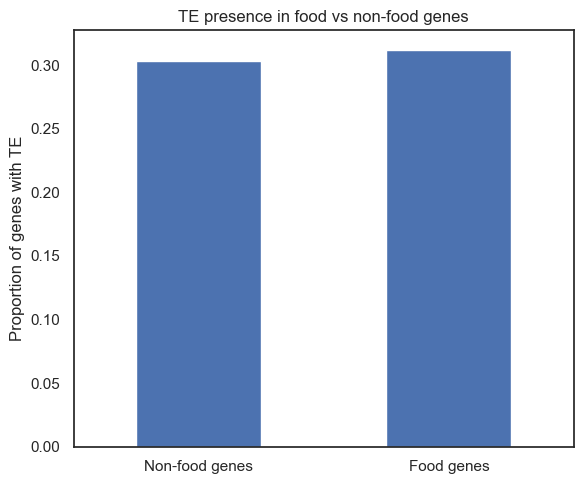

In [23]:
import matplotlib.pyplot as plt

prop = df.groupby("is_food")["has_TE"].mean()
prop.index = ["Non-food genes", "Food genes"]

plt.figure(figsize=(6,5))
prop.plot(kind="bar")

plt.ylabel("Proportion of genes with TE")
plt.title("TE presence in food vs non-food genes")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [24]:
## g:Profiler TEs##
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

gp.profile(organism="dmelanogaster", query=obj4_result["gen"].tolist(),
           sources=["GO:BP", "GO:MF", "GO:CC"])


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0009987,cellular process,6.349244e-09,True,"""Any process that is carried out at the cellul...",9318,3011,2536,11642,0.842245,0.272161,query_1,[GO:0008150]
1,GO:MF,GO:0005488,binding,8.577051e-09,True,"""The selective, non-covalent, often stoichiome...",7100,3047,1969,11914,0.646209,0.277324,query_1,[GO:0003674]
2,GO:CC,GO:0110165,cellular anatomical structure,2.986880e-07,True,"""A part of a cellular organism consisting of a...",10925,3150,2888,12293,0.916825,0.264348,query_1,[GO:0005575]
3,GO:CC,GO:0005737,cytoplasm,1.731889e-05,True,"""The contents of a cell excluding the plasma m...",5438,3150,1520,12293,0.482540,0.279515,query_1,"[GO:0005622, GO:0110165]"
4,GO:MF,GO:0016491,oxidoreductase activity,3.804085e-05,True,"""Catalysis of an oxidation-reduction (redox) r...",642,3047,222,11914,0.072859,0.345794,query_1,[GO:0003824]
5,GO:MF,GO:0004497,monooxygenase activity,1.783335e-03,True,"""Catalysis of the incorporation of one atom of...",125,3047,55,11914,0.018051,0.440000,query_1,[GO:0016491]
6,GO:CC,GO:0031090,organelle membrane,2.578799e-03,True,"""A membrane that is one of the two lipid bilay...",1425,3150,432,12293,0.137143,0.303158,query_1,"[GO:0016020, GO:0043227]"
7,GO:MF,GO:0043167,ion binding,3.420551e-03,True,"""Binding to an ion, a charged atoms or groups ...",3104,3047,884,11914,0.290121,0.284794,query_1,[GO:0036094]
8,GO:MF,GO:0005515,protein binding,3.921156e-03,True,"""Binding to a protein."" [GOC:go_curators]",3828,3047,1074,11914,0.352478,0.280564,query_1,[GO:0005488]
9,GO:BP,GO:0032502,developmental process,5.964973e-03,True,"""A biological process whose specific outcome i...",2938,3011,851,11642,0.282630,0.289653,query_1,[GO:0008150]


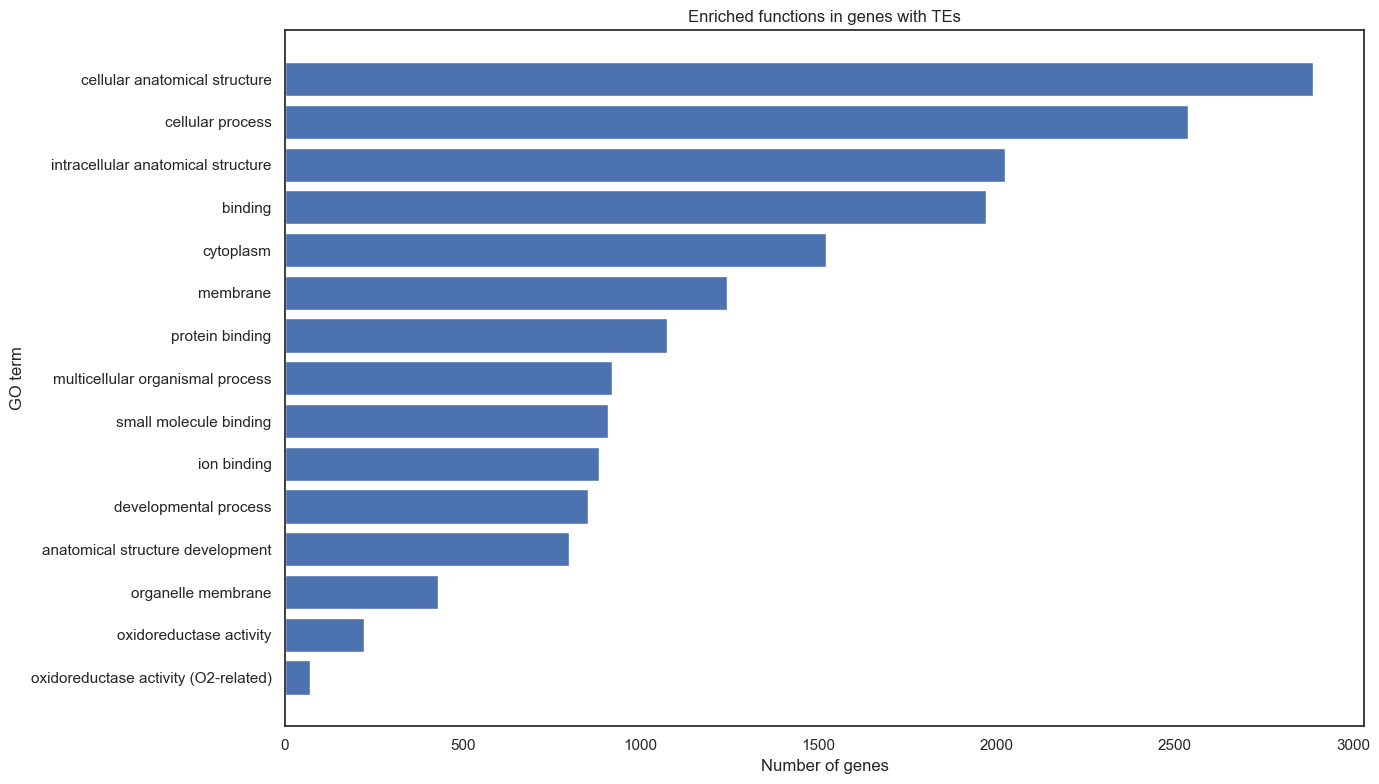

In [25]:
te_profile = gp.profile(
    organism="dmelanogaster",
    query=obj4_result["gen"].tolist(),
    sources=["GO:BP", "GO:MF", "GO:CC"],
    no_evidences=False
)

res_sig = te_profile[te_profile["p_value"] < 0.05]

# ordenar por número de genes
top = res_sig.sort_values("intersection_size", ascending=False).head(15)
top["name"] = top["name"].replace({
    "oxidoreductase activity, acting on paired donors, with incorporation or reduction of molecular oxygen":
    "oxidoreductase activity (O2-related)"
})

plt.figure(figsize=(14, 8))

plt.barh(
    top["name"],
    top["intersection_size"],
    height=0.8
)

plt.xlabel("Number of genes")
plt.ylabel("GO term")
plt.title("Enriched functions in genes with TEs")

plt.gca().invert_yaxis()
plt.subplots_adjust(left=0.4)
plt.tight_layout()
plt.show()

In [26]:
## g:Profiler en todos los genes ##
gp.profile(organism="dmelanogaster", query=df["gene"].tolist())

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:0009987,cellular process,4.732799e-221,True,"""Any process that is carried out at the cellul...",9318,10113,8608,11642,0.851182,0.923803,query_1,[GO:0008150]
1,GO:CC,GO:0005622,intracellular anatomical structure,3.742775e-154,True,"""A component of a cell contained within (but n...",7562,10633,7038,12293,0.661902,0.930706,query_1,[GO:0110165]
2,GO:CC,GO:0110165,cellular anatomical structure,1.445996e-132,True,"""A part of a cellular organism consisting of a...",10925,10633,9786,12293,0.920342,0.895744,query_1,[GO:0005575]
3,GO:MF,GO:0005488,binding,8.985661e-124,True,"""The selective, non-covalent, often stoichiome...",7100,10294,6576,11914,0.638819,0.926197,query_1,[GO:0003674]
4,GO:CC,GO:0043226,organelle,1.622807e-114,True,"""Organized structure of distinctive morphology...",6585,10633,6125,12293,0.576037,0.930144,query_1,[GO:0110165]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,GO:BP,GO:0051650,establishment of vesicle localization,4.505788e-02,True,"""The directed movement of a vesicle to a speci...",63,10113,63,11642,0.006230,1.000000,query_1,"[GO:0051648, GO:0051649, GO:0051656]"
821,GO:BP,GO:0060810,intracellular mRNA localization involved in pa...,4.505788e-02,True,"""Any process in which mRNA is transported to, ...",63,10113,63,11642,0.006230,1.000000,query_1,"[GO:0007389, GO:0008298]"
822,GO:BP,GO:0032868,response to insulin,4.711984e-02,True,"""Any process that results in a change in state...",111,10113,108,11642,0.010679,0.972973,query_1,[GO:0043434]
823,GO:BP,GO:0009060,aerobic respiration,4.837823e-02,True,"""The enzymatic release of energy from inorgani...",197,10113,187,11642,0.018491,0.949239,query_1,[GO:0045333]


In [27]:
## g:Profiler TEs vs Anotaciones##
from gprofiler import GProfiler
gp = GProfiler(return_dataframe=True)

gp_comparation_results = gp.profile(organism="dmelanogaster",
           query=obj4_result["gen"].tolist(),
           background=df["gene"].tolist(),
           sources=["GO:BP", "GO:MF", "GO:CC"],
           no_evidences=False)

gp_comparation_results.head()


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences
0,GO:MF,GO:0004497,monooxygenase activity,0.024974,True,"""Catalysis of the incorporation of one atom of...",116,4463,55,14708,0.012324,0.474138,query_1,[GO:0016491],"[CG14031, CG17970, CG14032, CG10833, CG10391, ...","[[IEA], [IEA], [IEA], [IEA], [IEA], [IEA], [IE..."


In [66]:
genes_mono = gp_comparation_results.iloc[0]["intersections"]
if isinstance(genes_mono, str):
    genes_mono = genes_mono.split(",")

mono_oxy_genes = obj4_result[
    obj4_result["gen"].isin(genes_mono)
]

mono_oxy_genes

,gen,gene_name,description,te_family_suzukii,te_class_suzukii,TE_has_TFBS
99,CG14031,cyp4ac3,Cytochrome P450,nf_157_PIFHARBINGER_1,DNA/PIFHARBINGER,False
100,CG17970,cyp4ac2,Cytochrome P450,nf_378_TIR_1,DNA/DNA,False
101,CG14032,cyp4ac1,Cytochrome P450,nf_378_TIR_1,DNA/DNA,False
105,CG10833,cyp28d1,Cytochrome P450,Mariner-1_DF,DNA/TC1MARINER,False
438,CG10391,cyp310a1,Cytochrome P450,nf_379_LINE_1,LINE/LINE,False
506,CG7249,cyp6a16,Cytochrome P450,nf_85_I_1,LINE/I,False
568,CG6730,cyp4d21,Cytochrome P450,nf_360_HELITRON_1,DNA/RC,False
682,CG8864,cyp28a5,Cytochrome P450,nf_23_HELITRON_1,DNA/RC,True
760,CG6713,nos,Nitric oxide,nf_294_TIR_1,DNA/DNA,False
1087,CG17577,cyp9h1,Cytochrome P450,nf_81_I_1,LINE/I,True


In [42]:
freq_mono = mono_oxy_genes['te_class_suzukii'].value_counts(normalize=True)
freq_obj4 = obj4_result['te_class_suzukii'].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    'Monooxygenase genes': freq_mono,
    'All genes': freq_obj4
}).fillna(0)

comparison_df['total'] = comparison_df.sum(axis=1)
comparison_df = comparison_df.sort_values('total', ascending=False).drop(columns='total')

comparison_df = comparison_df * 100

In [45]:
mdg4_tes = obj4_result[obj4_result['gene_name'].str.contains('mdg4')]
mdg4_tes.head()

,gen,gene_name,description,te_family_suzukii,te_class_suzukii,TE_has_TFBS
3083,CG32491,mod(mdg4),modifier of,nf_25_CR1_1,LINE/CR1,False
3084,CG32491,mod(mdg4),modifier of,nf_25_CR1_1,LINE/CR1,False
3085,CG32491,mod(mdg4),modifier of,nf_25_CR1_1,LINE/CR1,False
3086,CG32491,mod(mdg4),modifier of,nf_25_CR1_1,LINE/CR1,False
3087,CG45988,pre-mod(mdg4)-aa,,nf_25_CR1_1,LINE/CR1,False


In [31]:
transcription_factor_TEs = [
    "Copia-1_DBi-I_1", "Gypsy-11_DTa-I", "Gypsy-16_DWil-LTR_inc_1",
    "Gypsy-30_DWil-I", "Gypsy-30_DWil-I_1", "Gypsy-53_DEl-I_inc_1",
    "Gypsy17-LTR_Dya", "I-1_DT", "I-2_DAn", "I-2_DEu", "I-2_DF",
    "I-3_DBp", "I-6_DBp", "I_DM", "Jockey-2_DK",
    "Polinton-1_DBi_2", "nf_100_I_1", "nf_106_GYPSY_1",
    "nf_108_LINE_1", "nf_116_TIR_1", "nf_119_I_2",
    "nf_11_MAVERICK_1", "nf_129_GYPSY_1", "nf_132_GYPSY_1",
    "nf_134_I_1", "nf_137_I_2", "nf_138_GYPSY_1",
    "nf_142_GYPSY_1", "nf_143_GYPSY_2", "nf_151_TRANSIB_1",
    "nf_152_GYPSY_1", "nf_153_TRANSIB_1", "nf_158_LTR_1",
    "nf_162_I_1", "nf_165_LINE_1", "nf_165_LINE_4",
    "nf_168_LTR_1", "nf_172_PIGGYBAC_1",
    "nf_183_LTR_1", "nf_183_LTR_2", "nf_18_LTR_1",
    "nf_196_TIR_1", "nf_205_CR1_2", "nf_211_COPIA_1",
    "nf_213_GYPSY_1", "nf_23_HELITRON_1", "nf_26_COPIA_1",
    "nf_282_LINE_1", "nf_30_GYPSY_1", "nf_31_LTR_1",
    "nf_377_MITE_1", "nf_381_TIR_1", "nf_3_MAVERICK_1",
    "nf_43_LTR_1", "nf_45_LTR_1", "nf_47_GYPSY_1",
    "nf_51_LTR_1", "nf_52_LTR_1", "nf_61_LTR_1",
    "nf_62_GYPSY_1", "nf_62_GYPSY_2", "nf_63_R1_1",
    "nf_75_I_1", "nf_77_I_1", "nf_80_I_1", "nf_81_I_1",
    "nf_83_LINE_1", "nf_91_LINE_1", "nf_93_COPIA_1",
    "nf_95_I_1", "nf_9_MAVERICK_1", "nf_9_MAVERICK_2"
]

transcription_factor_TEs = set(transcription_factor_TEs)

In [32]:
obj4_result["TE_has_TFBS"] = obj4_result["te_family_suzukii"].isin(transcription_factor_TEs)

gene_te_summary = obj4_result.groupby("gen").agg({
    "TE_has_TFBS": "max",
    "gen": "count"
}).rename(columns={"gen": "TE_count"}).reset_index()

df = df.merge(gene_te_summary, left_on="gene", right_on="gen", how="left")

df["TE_has_TFBS"] = df["TE_has_TFBS"].fillna(0).astype(int)
df["TE_count"] = df["TE_count"].fillna(0)

In [33]:
from scipy.stats import fisher_exact

contingency = pd.crosstab(df["is_food"], df["TE_has_TFBS"])
contingency = contingency.reindex(index=[0,1], columns=[0,1], fill_value=0)
contingency = contingency.astype(int)

print("Tabla de contingencia:")
print(contingency)

table = contingency.values
oddsratio, pvalue = fisher_exact(table)

print("\nResultados Fisher:")
print("Odds ratio:", oddsratio)
print("p-value:", pvalue)

Tabla de contingencia:
TE_has_TFBS      0     1
is_food                 
0            12373  1999
1              286    54

Resultados Fisher:
Odds ratio: 1.1686647519563977
p-value: 0.30308273155246146


In [34]:
results = []

for _, row in gp_comparation_results.iterrows():
    go_id = row["native"]
    go_name = row["name"]
    genes_go = row["intersections"]

    if isinstance(genes_go, str):
        genes_go = genes_go.split(",")

    genes_go = set(genes_go)
    df["is_go"] = df["gene"].isin(genes_go).astype(int)

    contingency = pd.crosstab(df["is_go"], df["TE_has_TFBS"])
    contingency = contingency.reindex(index=[0,1], columns=[0,1], fill_value=0)
    contingency = contingency.astype(int)

    if contingency.values.sum() == 0:
        continue

    try:
        oddsratio, pvalue = fisher_exact(contingency.values)
    except:
        oddsratio, pvalue = None, None

    results.append({
        "GO_ID": go_id,
        "GO_name": go_name,
        "odds_ratio": oddsratio,
        "p_value": pvalue,
        "genes_in_GO": len(genes_go)
    })

results_df = pd.DataFrame(results)

In [35]:
df["TE_has_TFBS"].value_counts()

TE_has_TFBS
0    12659
1     2053
Name: count, dtype: int64

In [36]:
from statsmodels.stats.multitest import multipletests

results_df["p_adj"] = multipletests(
    results_df["p_value"],
    method="fdr_bh"
)[1]

sig = results_df[results_df["p_adj"] < 0.05]

sig.sort_values("odds_ratio", ascending=False).head(20)

,GO_ID,GO_name,odds_ratio,p_value,genes_in_GO,p_adj
0,GO:0004497,monooxygenase activity,6.011793,4.937458e-10,55,4.937458e-10


In [81]:
all_mono_genes = set(genes_mono)
genes_with_te = set(obj4_result["gen"])

mono_with_te = all_mono_genes.intersection(genes_with_te)
prop_mono = len(mono_with_te) / len(all_mono_genes)

all_genes = set(df["gene"])
genes_with_te_all = set(obj4_result["gen"])
prop_all = len(genes_with_te_all) / len(all_genes)

In [82]:
df_plot = pd.DataFrame({
    "Group": ["All genes", "Monooxygenase genes"],
    "Proportion": [prop_all, prop_mono]
})